## Requisitos

Capturar una imagen utilizando la cámara oscura.

## Instrucciones

- convertir la imagen a HSV
- separar canales H, S y V
- ecualizar únicamente el canal V
- recomponer la imagen



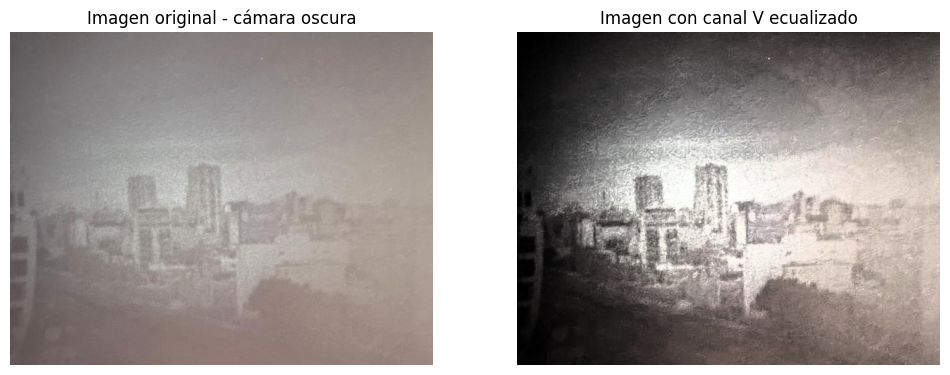

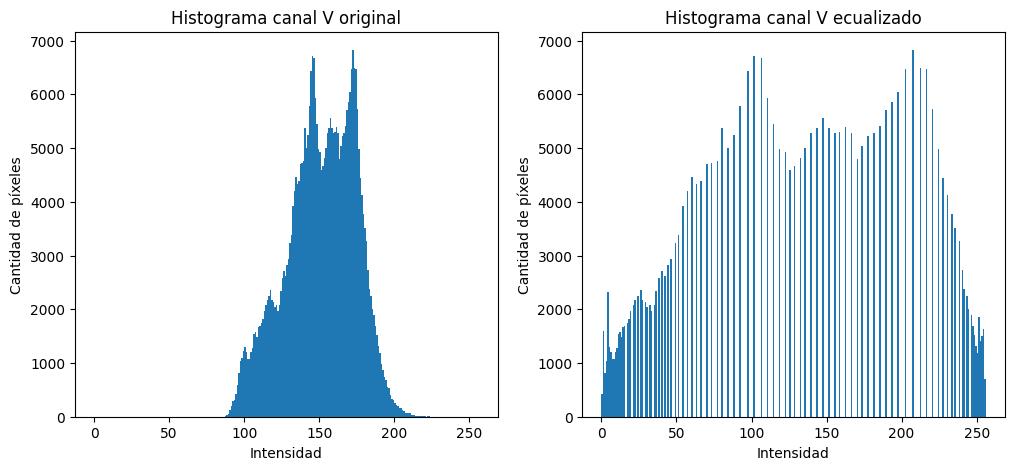

In [7]:
import cv2
import matplotlib.pyplot as plt

# 1. Cargar la imagen capturada con cámara oscura
imagen = cv2.imread("camara_oscura.jpeg")
imagen = cv2.rotate(imagen, cv2.ROTATE_180)

# Verificamos que la imagen se haya cargado correctamente
if imagen is None:
    print("Error: no se pudo cargar la imagen. Revisá el nombre o la ruta del archivo.")
else:
    # OpenCV carga la imagen en formato BGR
    imagen_rgb = cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB)

    # 2. Convertir la imagen a HSV
    imagen_hsv = cv2.cvtColor(imagen, cv2.COLOR_BGR2HSV)

    # 3. Separar los canales H, S y V
    h, s, v = cv2.split(imagen_hsv)

    # 4. Ecualizar únicamente el canal V
    v_ecualizado = cv2.equalizeHist(v)

    # 5. Recomponer la imagen HSV con el canal V ecualizado
    imagen_hsv_ecualizada = cv2.merge([h, s, v_ecualizado])

    # 6. Convertir nuevamente de HSV a BGR y luego a RGB para mostrar
    imagen_ecualizada_bgr = cv2.cvtColor(imagen_hsv_ecualizada, cv2.COLOR_HSV2BGR)
    imagen_ecualizada_rgb = cv2.cvtColor(imagen_ecualizada_bgr, cv2.COLOR_BGR2RGB)

    # Mostrar resultados
    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1)
    plt.imshow(imagen_rgb)
    plt.title("Imagen original - cámara oscura")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(imagen_ecualizada_rgb)
    plt.title("Imagen con canal V ecualizado")
    plt.axis("off")

    plt.show()

    # Mostrar histogramas del canal V original y V ecualizado

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.hist(v.ravel(), bins=256, range=[0, 256])
    plt.title("Histograma canal V original")
    plt.xlabel("Intensidad")
    plt.ylabel("Cantidad de píxeles")

    plt.subplot(1, 2, 2)
    plt.hist(v_ecualizado.ravel(), bins=256, range=[0, 256])
    plt.title("Histograma canal V ecualizado")
    plt.xlabel("Intensidad")
    plt.ylabel("Cantidad de píxeles")

    plt.show()